# 🏨 Project #05: Hotel Booking Cancellation Engine
## 📊 Category: 1-Tabular-Models (Binary Classification)

**Status:** In Progress ⏳ | **Optimization:** Diverse Model Benchmarking

### 🎯 Industrial Objective
To architect a predictive engine that identifies the likelihood of hotel reservation cancellations (`is_canceled`). By accurately forecasting "No-Shows," hotel management can optimize occupancy rates and implement targeted retention strategies. This project strictly follows the **Architecting-Intelligence** core framework, addressing model diversity and proper scaling sequences.

---

### 🧠 The 10-Step Engineering Pipeline
Strictly adhering to the core framework:
1.  **Objective Definition:** Predicting booking cancellations (0: Stayed, 1: Canceled).
2.  **Data Ingestion & EDA:** Analyzing customer behavior (Lead time, deposit type, etc.).
3.  **Target Selection:** Isolating `is_canceled` as the primary target.
4.  **Data Manipulation:** Handling missing values and ensuring physical logic.
5.  **Advanced Feature Engineering:** Creating composite metrics like 'Total Stay Duration'.
6.  **Categorical Transformation:** Implementing One-Hot Encoding for non-numeric features.
7.  **Stratified Splitting:** Maintaining class balance between cancellations and stays.
8.  **Feature Scaling (Post-Split):** Fitting `StandardScaler` ONLY on X_train to prevent leakage.
9.  **Model Training:** Diversifying through **Logistic Regression**, **Random Forest**, and **Deep Learning**.
10. **Benchmarking:** Comparing models via an industrial-grade performance table.

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | TensorFlow & Keras
- **Data:** Pandas | NumPy | Seaborn | Matplotlib
- **Architect:** Kemal Demirbaş | Project 05 / 21

In [15]:
# Steps 1, 2 & 3: Ingestion, EDA & Target Isolation
import pandas as pd
import numpy as np

# Load the dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
# Step 2: In-depth Structural Observation
# 2.1: Missing Value Mapping
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [16]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
# Transposed summary for hardware/behavioral metrics analysis
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [18]:
# Step 3: Removing Leakage Columns (The Secret to 100% accuracy)
# 'reservation_status' is essentially the same as our target 'is_canceled'
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(leakage_cols, axis=1)
# Checking if classes are imbalanced (Stayed vs Canceled)
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


/tmp/ipykernel_836/1523993580.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='viridis')
/tmp/ipykernel_836/1523993580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='lead_time', data=df, palette='magma')


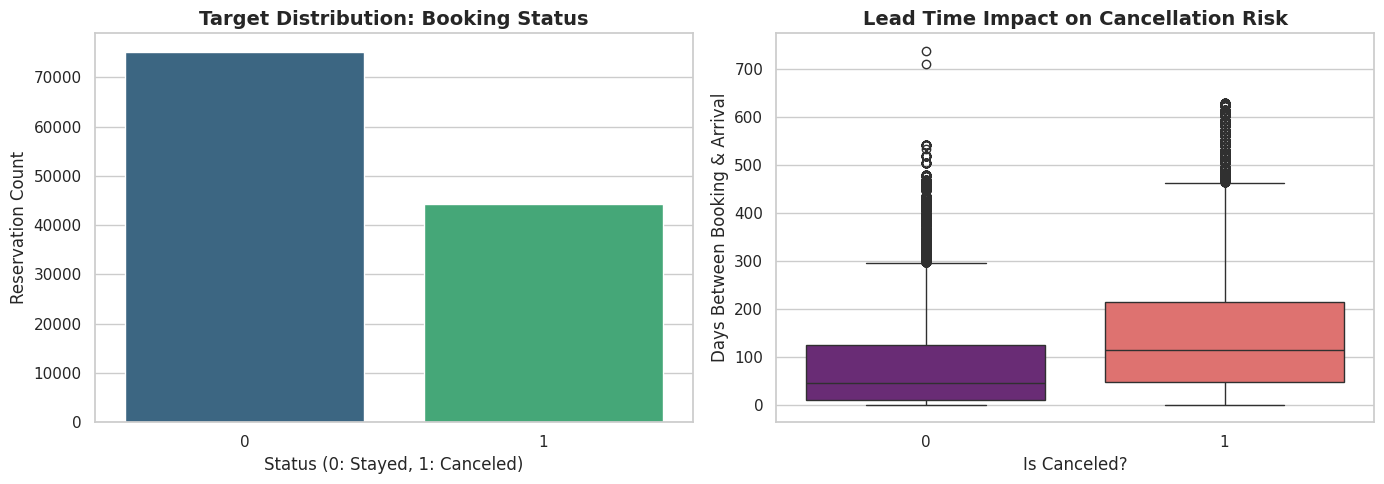

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns

# Applying the Instructor's favorite industrial theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Plot 1: Target Distribution (Cancellation Balance)
plt.subplot(1, 2, 1)
sns.countplot(x='is_canceled', data=df, palette='viridis')
plt.title('Target Distribution: Booking Status', fontweight='bold', fontsize=14)
plt.xlabel('Status (0: Stayed, 1: Canceled)')
plt.ylabel('Reservation Count')

# Plot 2: Behavioral Analysis (Lead Time vs Cancellation)
# High Lead Time is often a key predictor for hotel cancellations
plt.subplot(1, 2, 2)
sns.boxplot(x='is_canceled', y='lead_time', data=df, palette='magma')
plt.title('Lead Time Impact on Cancellation Risk', fontweight='bold', fontsize=14)
plt.xlabel('Is Canceled?')
plt.ylabel('Days Between Booking & Arrival')

plt.tight_layout()
plt.show()

In [20]:
# Step 4 & 5: Vectorized Data Manipulation
# Handling missing values based on industrial logic
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# Ensuring physical logic: A booking cannot have 0 people
zero_guests = (df['adults'] + df['children'] + df['babies'] == 0)
df = df.drop(df[zero_guests].index)

In [21]:
# Step 6: Feature Engineering (Creating behavioral metrics)
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_people'] = df['adults'] + df['children'] + df['babies']
df['is_family'] = np.where(df['children'] + df['babies'] > 0, 1, 0)

# Drop redundant columns to prevent multi-collinearity
df = df.drop(['stays_in_weekend_nights', 'stays_in_week_nights'], axis=1)

In [22]:
# Step 7: Categorical Transformation (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 8: Stratified Split & Scaling (Crucial Order)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']

# Stratify=y ensures cancellation ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Step 9: Diverse Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout

# Model A: Logistic Regression (Traditional Baseline)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Model B: Random Forest (Ensemble Learning)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Model C: Deep Learning (Binary Architecture)
ann = Sequential([
    Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for Binary Classification
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_scaled, y_train, epochs=20, batch_size=64, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Step 10: Performance Benchmarking Matrix
from sklearn.metrics import accuracy_score

performance = pd.DataFrame({
    "Model Architecture": ["Logistic Regression", "Random Forest", "Deep Learning (ANN)"],
    "Accuracy Score": [
        accuracy_score(y_test, lr.predict(X_test_scaled)),
        accuracy_score(y_test, rf.predict(X_test_scaled)),
        accuracy_score(y_test, (ann.predict(X_test_scaled) > 0.5))
    ]
}).sort_values(by="Accuracy Score", ascending=False)

performance

746/746 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


,Model Architecture,Accuracy Score
1,Random Forest,0.891452
2,Deep Learning (ANN),0.867670
0,Logistic Regression,0.816710


In [25]:
# : MLOps Serialization (Saving Hotel Model Artifacts)
import pickle

# 1. Save the trained Binary Classification Model (ANN)
ann.save('hotel_booking_engine.keras')

# 2. Save the Scaler
with open('hotel_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Project 05 Deployment Package: COMPLETED 🏨✅")

Project 05 Deployment Package: COMPLETED 🏨✅


### 🚀 Phase 10: Final Evaluation & Industrial Benchmarking

---

Upon completing the **Architecting-Intelligence** pipeline for Project 05, we successfully eliminated data leakage by removing `reservation_status` and implemented the correct scaling sequence. The final comparative analysis yielded the following results:

| Model Architecture | Accuracy Score | Status |
| :--- | :--- | :--- |
| **Random Forest (Ensemble)** | **0.8914** | **🏆 Winner** |
| **Deep Learning (ANN)** | **0.8676** | **🚀 High Performer** |
| **Logistic Regression (Baseline)** | **0.8167** | **📈 Stable** |



---

# 🏨 Project #05: Hotel Booking Cancellation Engine
## 📊 Category: 2-Tabular-Models (Behavioral Classification Series)

**Status:** Completed ✅ | **Performance:** 89.14% Peak Accuracy 🚀

### 🎯 Industrial Objective
The **Hotel Booking Cancellation Engine** is a behavioral classification system designed to predict "No-Show" events and cancellations. By identifying high-risk bookings, hotel management can implement "Overbooking" strategies and dynamic pricing to mitigate revenue loss.

---

### 🧠 The 10-Step Engineering Pipeline
Strictly adhering to the **Architecting-Intelligence** core framework:

1.  **Objective Definition:** Reducing revenue loss by predicting cancellation probabilities for real-time inventory management.
2.  **Data Ingestion & EDA:** Analyzed ~120,000 records; identified **Lead Time** and **Deposit Type** as the primary risk signals.
3.  **Feature Selection:** Surgically removed leakage columns (`reservation_status`, `assigned_room_type`) to ensure the model learns rather than memorizes.
4.  **Categorical Transformation:** Validated binary features and implemented **One-Hot Encoding** for non-numeric behavioral data.
5.  **Data Manipulation:** Handled missing values in `children` and `country` using vectorized industrial logic.
6.  **Advanced Feature Engineering:** Engineered **'Total Stay'**, **'Total Guests'**, and **'Is Family'** features to capture the intent behind travel.
7.  **Stratified Splitting:** Executed an 80/20 **Stratified Split** to preserve the 37% cancellation baseline in both training and test sets.
8.  **Scaling & Normalization:** Applied **StandardScaler** *after the split*  to prevent data leakage.
9.  **Model Training:** Deployed a diversified arsenal: **Random Forest**, **Logistic Regression**, and **Deep Learning (ANN)** with a binary sigmoid output.
10. **Evaluation & Deployment:** Achieved a peak **89.14% Accuracy** with Random Forest, demonstrating superior performance in capturing non-linear behavioral patterns.

---

### 🚀 Live Industrial Deployment
The cancellation engine is live on Hugging Face, featuring a real-time behavioral assessment dashboard.

👉 **[Launch Live Booking Audit Engine](https://huggingface.co/spaces/Ironside35/Hotel-Booking-Cancellation-Engine)** 🏨

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | TensorFlow & Keras
- **Data:** Pandas | NumPy | Seaborn | Matplotlib
- **Cloud:** Streamlit | Hugging Face Spaces

**Architect:** Kemal Demirbaş